## 1 Identify Camera Frame Keypoints with GeoAware-SC

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
0.28125 0
0.28055555555555556 79
[ 550 1175 1175 1160 1025  950 1050 1000] [154.6875  330.46875 330.46875 326.25    288.28125 267.1875  295.3125
 281.25   ]


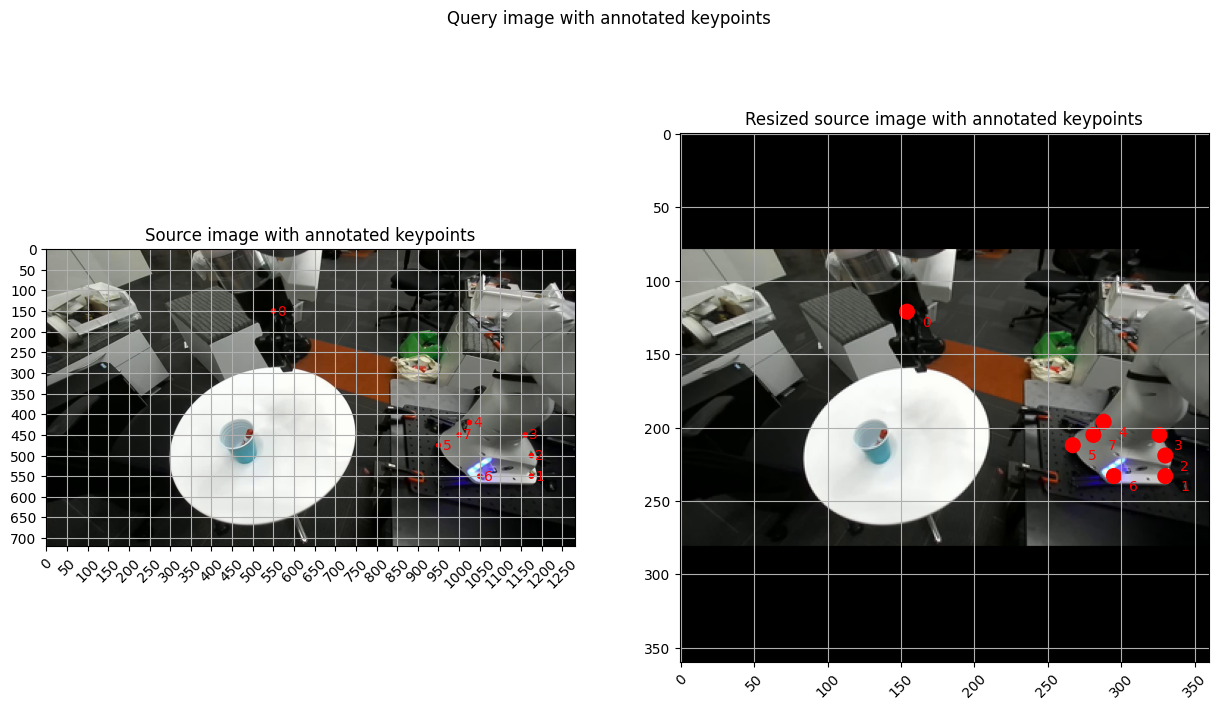

In [53]:
%load_ext autoreload
%autoreload 2
import os, sys, torch, numpy as np, json
from os.path import join, exists
import matplotlib.pyplot as plt
import IPython.display as ipd
sys.path.append('./utils')
from PIL import Image, ImageDraw
from utils.utils_correspondence import resize
from utils.utils_geoaware_inference import (
    read_mp4, load_annotation_json, load_img, show_img_and_annotation, VideoInference
)
from utils.utils_calibration import (
    get_repo_root, TrajectoryDataset, CalibratorCam2Base, imgs_to_gif
)


''' 1. Load source image and annotated keypoints'''
src_img_path = join(get_repo_root(), 
                    f'assets/droid_examples/droid_Thu_May_11_13_33_20_2023/img_thumbnails/{(img_name:="third_person_good.jpg")}')
kps_ann_path = join(get_repo_root(), 
                    'assets/droid_examples/droid_Thu_May_11_13_33_20_2023/keypoint_annotation.json')
img_arr_source = load_img(src_img_path)
kp_query_coords = np.array(load_annotation_json(kps_ann_path)[img_name])

''' 2. Resize source image and re-calculate keypoint locations for efficient inference '''
img_size = 360
resize_ret = resize(orig_img:=Image.open(src_img_path).convert('RGB'), 
                    target_res=img_size, 
                    resize=True, to_pil=True, return_kp_coord_info=True)
img1 = resize_ret.canvas

print(resize_ret.x_scale, resize_ret.x_offset)
print(resize_ret.y_scale, resize_ret.y_offset)
print(kp_query_coords[:,0], kp_query_coords[:,0] * resize_ret.x_scale + resize_ret.x_offset)
kp_query_coords_resized = kp_query_coords.copy()
kp_query_coords_resized[:,0] = kp_query_coords[:,0] * resize_ret.x_scale + resize_ret.x_offset
kp_query_coords_resized[:,1] = kp_query_coords[:,1] * resize_ret.y_scale + resize_ret.y_offset

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle("Query image with annotated keypoints")
ax1.set_title("Source image with annotated keypoints")
ax2.set_title("Resized source image with annotated keypoints")
show_img_and_annotation(ax1, img_arr_source, kp_query_coords)
show_img_and_annotation(ax2, np.array(img1), kp_query_coords_resized)

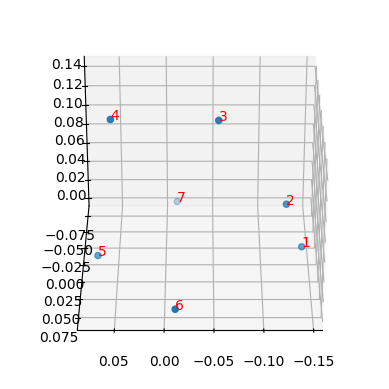

In [2]:
''' 3. Confirm keypoint locations in robot's canonical frame match with annotated keypoints 
NOTE: Ideally all keypoints should be on the robot joints, however, a lot of the trajectrories
have very bad joint visibilities (like this eample). For now the workaround is to use the
following keypoints on the robot base with the hope that they are visible in most of the trajectories.
'''
import numpy as np, matplotlib.pyplot as plt
verts_3d = np.array([
    [-1.43076244e-01, -2.14468290e-03,  8.92312189e-03],   # In Robot's canonical frame
    [-1.25680570e-01,  6.31571448e-04,  5.56254291e-02],
    [-5.49979992e-02, -8.49999997e-05,  1.40000001e-01],
    [ 5.49880005e-02, -1.55699998e-03,  1.40000001e-01],
    [ 7.15439990e-02,  3.29000002e-04,  1.34900003e-03],
    [-1.10056000e-02,  8.00555708e-02,  3.85714277e-03],
    [-1.09613143e-02, -8.00555708e-02,  3.85714277e-03]], dtype=np.float32)

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.scatter(verts_3d[:,0], verts_3d[:,1], verts_3d[:,2])
for i, (x,y,z) in enumerate(verts_3d):
    ax.text(x, y, z, f"{i+1}", color='red')
ax.view_init(elev=30, azim=90)  # Ad

In [55]:
''' 4. Infer keypoint matches in a query video '''
mp4_path = join(get_repo_root(), 
                'assets/droid_examples/droid_Thu_May_11_13_33_20_2023/recordings/MP4/29838012_left.mp4')
mp4_out_path = join(get_repo_root(), 'output.mp4')
out_keypoint_path = join(get_repo_root(), 'keypoint_inference_result.npz')
video_subsample_stride = 10
video_inference = VideoInference(img1, kp_query_coords_resized, mp4_path, img_size,
                                 num_patches = 40,
                                 out_video_path = mp4_out_path,
                                 out_keypoint_path = out_keypoint_path,
                                 video_subsample_stride = video_subsample_stride,
                                 img_affine_transform={'x_scale': resize_ret.x_scale,
                                                       'y_scale': resize_ret.y_scale,
                                                       'x_offset': resize_ret.x_offset,
                                                       'y_offset': resize_ret.y_offset})
video_inference.infer_video()

/home/kyle/miniforge3/envs/geo-aware/lib/python3.9/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning:

`torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.

/home/kyle/miniforge3/envs/geo-aware/lib/python3.9/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning:

`torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.



LatentDiffusion: Running in eps-prediction mode
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 1280, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 1280, con

/home/kyle/miniforge3/envs/geo-aware/lib/python3.9/site-packages/huggingface_hub/file_download.py:1150: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.

/home/kyle/miniforge3/envs/geo-aware/lib/python3.9/site-packages/transformers/modeling_utils.py:415: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowli

Video saved to /home/kyle/repos/GeoAware-SC/output.mp4
Cam keypoint inference result saved to /home/kyle/repos/GeoAware-SC/keypoint_inference_result.npz


## 2 PnP Camera Pose Estimation with inferred keypoint correspondences

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[2024-12-08 05:27:07 UTC][ZED][INFO] Logging level INFO
[2024-12-08 05:27:07 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[2024-12-08 05:27:07 UTC][ZED][INFO] [Init]  Serial Number: S/N 23404442
[2024-12-08 05:27:07 UTC][ZED][INFO] Logging level INFO
[2024-12-08 05:27:07 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[2024-12-08 05:27:07 UTC][ZED][INFO] [Init]  Serial Number: S/N 19824535
[2024-12-08 05:27:07 UTC][ZED][INFO] Logging level INFO
[2024-12-08 05:27:07 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[2024-12-08 05:27:07 UTC][ZED][INFO] [Init]  Serial Number: S/N 29838012
[2024-12-08 05:27:11 UTC][ZED][WARNING] END OF SVO FILE REACHED in sl::ERROR_CODE sl::Camera::grab(sl::RuntimeParameters)


Rendering frames for varied_camera_2_left: 100%|██████████| 7/7 [00:04<00:00,  1.66it/s]
OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


Calibration completed for varied_camera_2_left, images saved at assets/calibration_results/varied_camera_2_left


Writing mp4 video: 100%|██████████| 7/7 [00:00<00:00, 159.43it/s]


Video saved to /home/kyle/repos/GeoAware-SC/assets/droid_examples/droid_Thu_May_11_13_33_20_2023/calibration_result.mp4


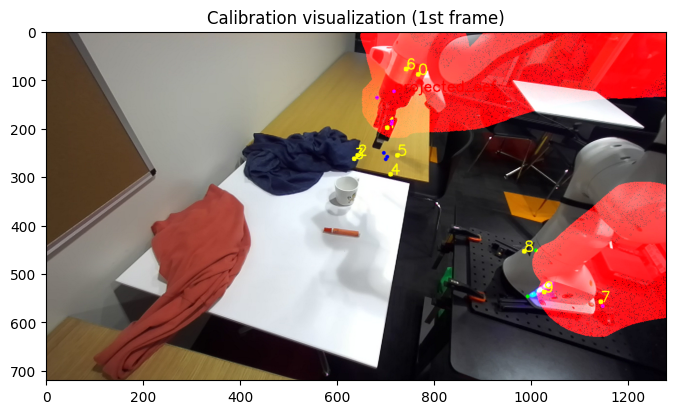

In [5]:
%load_ext autoreload
%autoreload 2
import os, sys, torch, numpy as np, imageio
from os.path import join, exists
sys.path.append('./third_party/droid')
sys.path.append('./utils')
# from IPython.display import display, Image
import IPython.display as ipd
from utils.utils_renderer import NVDiffrastRenderApiHelper
from utils.utils_geoaware_inference import (
    read_mp4, load_annotation_json, load_img, show_img_and_annotation, VideoInference, imgs_to_mp4
)
from utils.utils_calibration import (
    get_repo_root, TrajectoryDataset, CalibratorCam2Base
)
import matplotlib.pyplot as plt
# from utils.utils_calibration_solver import *
# from third_party.droid.droid.trajectory_utils.misc import load_trajectory
# from third_party.droid.droid.data_processing.timestep_processing import TimestepProcesser


data_dir = join(get_repo_root(), 'assets/droid_examples/droid_Thu_May_11_13_33_20_2023')
mp4_out_path = join(data_dir, 'calibration_result.mp4')
keypoint_path = join(get_repo_root(), 'keypoint_inference_result.npz')

trajectory_dataset = TrajectoryDataset(data_dir)
calibrator = CalibratorCam2Base(trajectory_dataset, 
                                keypoint_path, 
                                subsample_stride=10, 
                                cherry_pick=True)
calibrator.prepare_kalib_data()
imgs_dict = calibrator.calibrate_cameras()
imgs = np.array(imgs_dict['varied_camera_2_left'])[...,::-1].transpose(0,3,1,2)

fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.imshow(imgs[0].transpose(1,2,0))
ax.set_title('Calibration visualization (1st frame)')

imgs_to_mp4(imgs, mp4_out_path, fps=6)
ipd.display(ipd.Video(mp4_out_path, width=600))

In [6]:
calibrator.clean_up()   # removes temporary files

## Additional Notes

The calibration pipeline is simlar to [kalib](https://arxiv.org/pdf/2408.10562) with the following differences:
1. We use their idea of using the end effector position across frames to generate 2d-3d point correspondences for PnP solver.
2. We are not using there refinement procedure using differentiable renderer
    - But the mask renderer is NVDiffrast, which is the same as Kalib, and the image loss can be added with moderate effort.
3. We use a different set of keypoints for the robot base (see examples above).